C:\Users\mtermos\AppData\Local\Temp\ipykernel_4540\641230276.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


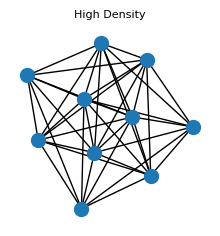

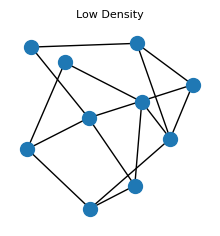

In [67]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def connected_gnm_graph(n, m, seed=None):
    """
    Create a connected graph on n nodes with m total edges:
    1) Start from a random spanning tree (n-1 edges).
    2) Add (m - (n-1)) edges uniformly at random from the remaining possible edges.
    """
    if seed is not None:
        random.seed(seed)
    # 1) start with a random tree
    G = nx.random_tree(n, seed=seed)
    # 2) pick extra edges
    all_possible = [(u, v) for u in range(n) for v in range(u+1, n) if not G.has_edge(u, v)]
    extra = random.sample(all_possible, m - (n - 1))
    G.add_edges_from(extra)
    return G

# Desired graphs
params = [
    (40, 'High Density'),
    (15, 'Low Density')
]

for edges, title in params:
    G = connected_gnm_graph(n=10, m=edges)
    plt.figure(figsize=(2, 2))
    # spring_layout with a bit of repulsion (k) for a “rounder” look
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    nx.draw(G, pos, with_labels=False, node_size=100)
    plt.title(title, fontsize=8)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


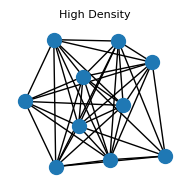

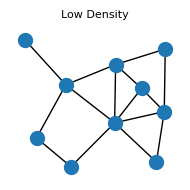

In [68]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def connected_gnm_graph(n, m, seed=None):
    if seed is not None:
        random.seed(seed)
    G = nx.random_tree(n, seed=seed)
    all_possible = [(u, v) for u in range(n) for v in range(u+1, n) if not G.has_edge(u, v)]
    extra = random.sample(all_possible, m - (n - 1))
    G.add_edges_from(extra)
    return G

params = [
    (40, 'High Density'),
    (15, 'Low Density')
]

for edges, title in params:
    G = connected_gnm_graph(n=10, m=edges, seed=42)
    # create a transparent figure
    fig = plt.figure(figsize=(2, 2), facecolor='none')
    ax = fig.add_subplot(111, facecolor='none')
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    nx.draw(G, pos, with_labels=False, node_size=100, ax=ax)
    ax.set_title(title, fontsize=8)
    ax.axis('off')
    plt.tight_layout()
    # save with transparent background
    plt.savefig(f"{title.replace(' ', '_').lower()}.png",
                transparent=True,
                dpi=150,
                bbox_inches='tight',
                pad_inches=0)
    plt.show()
